# Table S1 final: Final clustering configurations and hyperparameters

This source-rebuilt table declares the frozen final configuration directly in the notebook and renders it with Matplotlib. It does not read a cached image, PDF, CSV, registry, or derived prediction table at runtime.


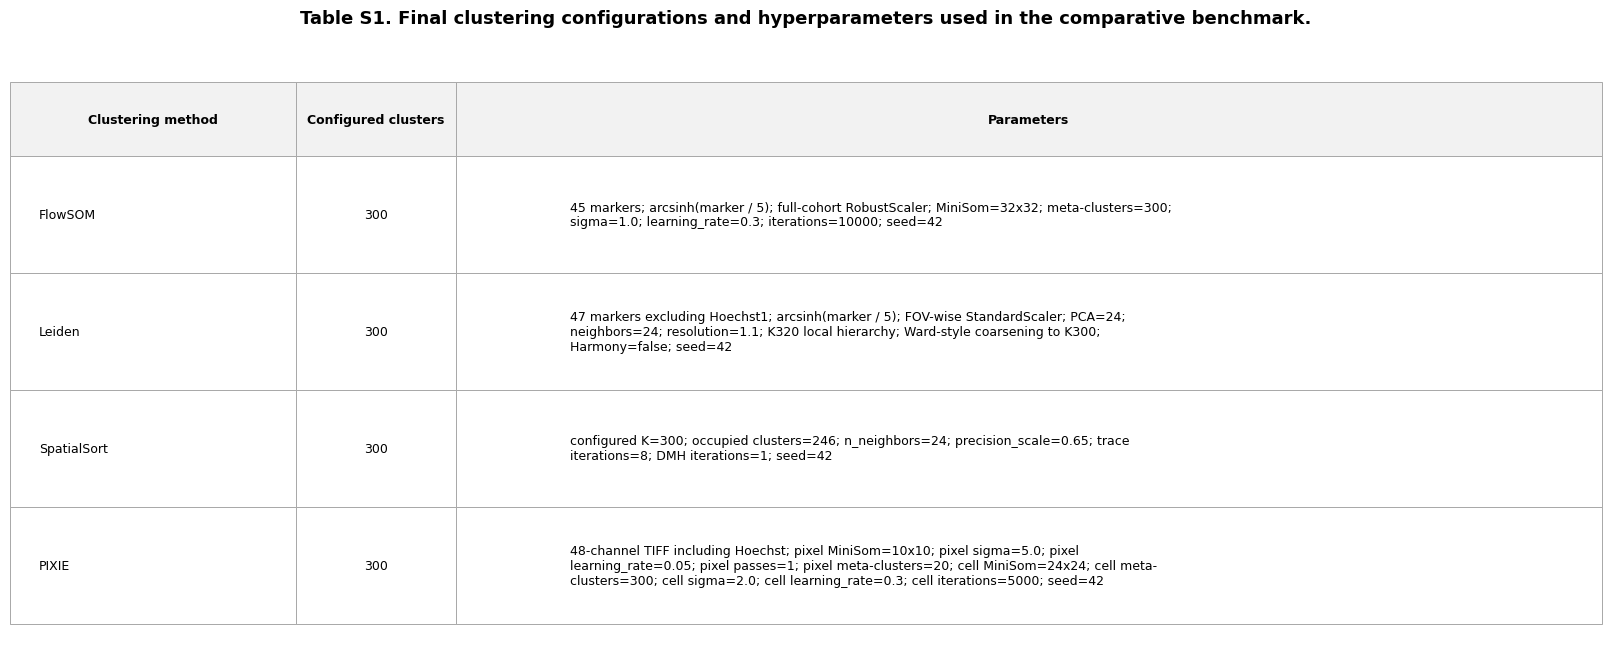

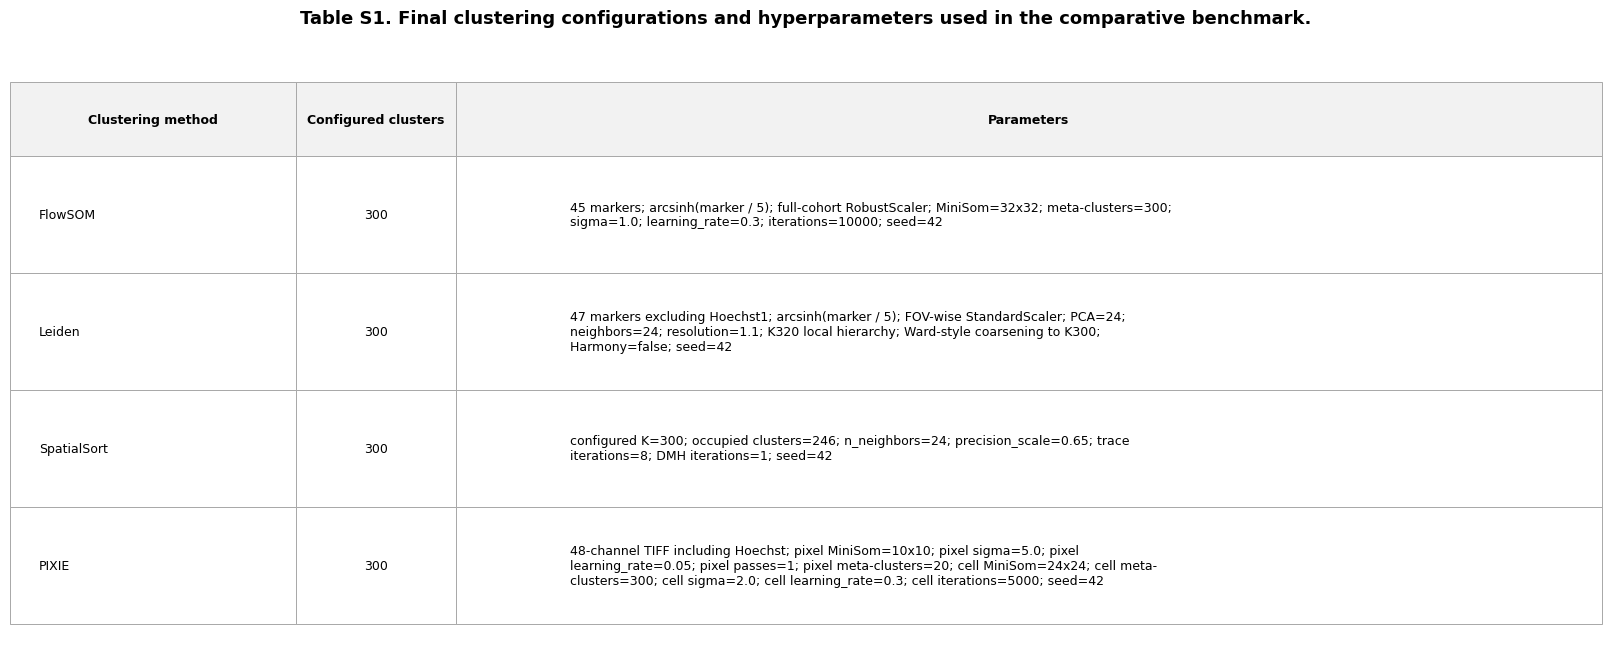

In [1]:
import os
from pathlib import Path
from textwrap import fill

import matplotlib.pyplot as plt
from IPython.display import display

TABLE_S1_TITLE = 'Table S1. Final clustering configurations and hyperparameters used in the comparative benchmark.'

# Frozen final analysis configuration. These settings are source code, not a runtime table input.
TABLE_S1_ROWS = [
    ('FlowSOM', '300', fill('45 markers; arcsinh(marker / 5); full-cohort RobustScaler; MiniSom=32x32; meta-clusters=300; sigma=1.0; learning_rate=0.3; iterations=10000; seed=42', width=92)),
    ('Leiden', '300', fill('47 markers excluding Hoechst1; arcsinh(marker / 5); FOV-wise StandardScaler; PCA=24; neighbors=24; resolution=1.1; K320 local hierarchy; Ward-style coarsening to K300; Harmony=false; seed=42', width=92)),
    ('SpatialSort', '300', fill('configured K=300; occupied clusters=246; n_neighbors=24; precision_scale=0.65; trace iterations=8; DMH iterations=1; seed=42', width=92)),
    ('PIXIE', '300', fill('48-channel TIFF including Hoechst; pixel MiniSom=10x10; pixel sigma=5.0; pixel learning_rate=0.05; pixel passes=1; pixel meta-clusters=20; cell MiniSom=24x24; cell meta-clusters=300; cell sigma=2.0; cell learning_rate=0.3; cell iterations=5000; seed=42', width=92)),
]

figure_s1, axis_s1 = plt.subplots(figsize=(16, 6.6), constrained_layout=True)
axis_s1.axis('off')
axis_s1.set_title(TABLE_S1_TITLE, fontsize=13, fontweight='bold', pad=16)
table_s1 = axis_s1.table(
    cellText=TABLE_S1_ROWS,
    colLabels=['Clustering method', 'Configured clusters', 'Parameters'],
    cellLoc='left',
    colLoc='center',
    colWidths=[0.18, 0.10, 0.72],
    loc='center',
)
table_s1.auto_set_font_size(False)
table_s1.set_fontsize(9)
for (row_index, column_index), cell in table_s1.get_celld().items():
    cell.set_edgecolor('#a8a8a8')
    cell.set_linewidth(0.7)
    cell.set_height(0.19 if row_index else 0.12)
    if row_index == 0:
        cell.set_facecolor('#f2f2f2')
        cell.set_text_props(weight='bold', ha='center', va='center')
    elif column_index == 1:
        cell.set_text_props(ha='center', va='center')
    else:
        cell.set_text_props(va='center')

TABLE_S1_FIGURE = figure_s1
display(TABLE_S1_FIGURE)


In [2]:
repo_root = next(parent for parent in (Path.cwd(), *Path.cwd().parents) if (parent / '.git').exists())
output_directory = Path(os.environ.get('SOURCE_REBUILD_OUTPUT_ROOT', repo_root / 'outputs/source_rebuilt')).expanduser()
output_directory.mkdir(parents=True, exist_ok=True)
table_s1_pdf = output_directory / 'Table_S1_final_source_rebuilt.pdf'
TABLE_S1_FIGURE.savefig(table_s1_pdf, bbox_inches='tight')
print(table_s1_pdf)


/private/tmp/cell-masks-two-pr.5iUWjB/repo/outputs/source_rebuilt/Table_S1_final_source_rebuilt.pdf
